In [16]:
import os
import numpy as np
import sys
from pathlib import Path
from src.prometheus_io import prom_query_range, prom_query_instant, test_connection 
import src.prometheus_io as pio
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt
import pandas as pd
import re

In [23]:
df = pd.read_csv('../exports/intensive_search_eda.csv')
df

,timestamp,cpu_by_svc__series_0 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.igvpqjhip9f7yajebzyz7o0bb.3fi3notwbk2tb7rp3w11d0j2e'},cpu_by_svc__series_1 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.pcm0p4f2ada7cfhyw9e47kgsy.9yvsig2urpoxuq05os6b85k5s'},cpu_by_svc__series_2 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.t8hzjgkdbn7sr8xr4ibxnsflv.ktnpvadt6vrdtiale10gjtkau'},cpu_by_svc__series_3 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.t9s38yiaa1pzw4hlf8zx6rk41.1r1y12e532nfp43qjmosjhohz'},cpu_by_svc__series_4 {'container_label_com_docker_swarm_task_name': 'chat-eda_elasticsearch.1.wgifab93cx3k9ow5u8pod2l3i'},cpu_by_svc__series_5 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.1.i1vkvkfqs5h1le59gdq3un33b'},cpu_by_svc__series_6 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.2.1p5rphjiwr9hmuwcfncvqqygi'},cpu_by_svc__series_7 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.3.ajp6hjlw9c738b02fk0ikka3z'},cpu_by_svc__series_8 {'container_label_com_docker_swarm_task_name': 'chat-eda_kafka.1.bwl6g8ubvdyrph3n56hq9lpdj'},...,mem_by_svc__series_13 {'container_label_com_docker_swarm_task_name': 'chat-eda_postgres-exporter.1.p1ln9va5ucxdx0e6i1tab6jjg'},mem_by_svc__series_14 {'container_label_com_docker_swarm_task_name': 'chat-eda_postgres.1.vgy49tvamktfdgzqxtxqutzj0'},mem_by_svc__series_15 {'container_label_com_docker_swarm_task_name': 'chat-eda_prometheus.1.n01bsv0z42u6c5z4hbewzpc3v'},mem_by_svc__series_16 {'container_label_com_docker_swarm_task_name': 'chat-eda_search-service.1.j1ulusj6eu998dvengr2iqtj9'},mem_by_svc__series_17 {'container_label_com_docker_swarm_task_name': 'chat-eda_user-service.1.t1widtiah4m8nyuqsol6h7md0'},mem_by_svc__series_18 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.1.ou4a71uyjiapfbjwsnodrgoci'},mem_by_svc__series_19 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.2.wqlv58jew59vjr61e19txxv8n'},mem_by_svc__series_20 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.3.sb0sl89720w571sqcfil33e2x'},k6_users__series_0 {},http_rt_latency__series_0 {}
0,2026-04-27 16:52:48.388000011+00:00,0.035777,0.033055,0.031818,0.032949,0.009995,0.0,0.0,0.0,0.022929,...,8798208.0,53518336.0,101609472.0,338182144.0,1.230967e+09,267825152.0,272175104.0,270782464.0,NaN,NaN
1,2026-04-27 16:52:53.388000011+00:00,0.035777,0.034568,0.035399,0.032949,0.009995,0.0,0.0,0.0,0.023081,...,8798208.0,53518336.0,101634048.0,338182144.0,1.230967e+09,267825152.0,272175104.0,270782464.0,NaN,NaN
2,2026-04-27 16:52:58.388000011+00:00,0.035477,0.034568,0.035554,0.032220,0.009265,0.0,0.0,0.0,0.021197,...,8798208.0,52977664.0,101634048.0,338481152.0,1.231000e+09,267825152.0,272179200.0,272384000.0,NaN,NaN
3,2026-04-27 16:53:03.388000011+00:00,0.035477,0.035321,0.034976,0.032220,0.009265,0.0,0.0,0.0,0.021197,...,8404992.0,52977664.0,101621760.0,338481152.0,1.231000e+09,267829248.0,272179200.0,272384000.0,NaN,NaN
4,2026-04-27 16:53:08.388000011+00:00,0.034559,0.035321,0.034976,0.031711,0.009166,0.0,0.0,0.0,0.022983,...,8404992.0,52981760.0,101621760.0,338505728.0,1.231102e+09,267829248.0,272179200.0,272728064.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596,2026-04-27 17:42:28.388000011+00:00,0.036109,0.030998,0.033899,0.033321,0.008385,0.0,0.0,0.0,0.016901,...,9027584.0,52436992.0,126705664.0,641572864.0,6.011945e+08,274616320.0,275783680.0,276877312.0,1.0,0.552824
597,2026-04-27 17:42:33.388000011+00:00,0.036109,0.031602,0.034722,0.033321,0.008385,0.0,0.0,0.0,0.016571,...,9023488.0,52436992.0,126734336.0,641572864.0,6.011945e+08,274616320.0,275783680.0,276877312.0,1.0,0.552824
598,2026-04-27 17:42:38.388000011+00:00,0.035573,0.031602,0.035381,0.035202,0.008647,0.0,0.0,0.0,0.017227,...,9023488.0,53121024.0,126722048.0,641835008.0,6.011945e+08,274616320.0,275779584.0,276877312.0,1.0,0.552824
599,2026-04-27 17:42:43.38

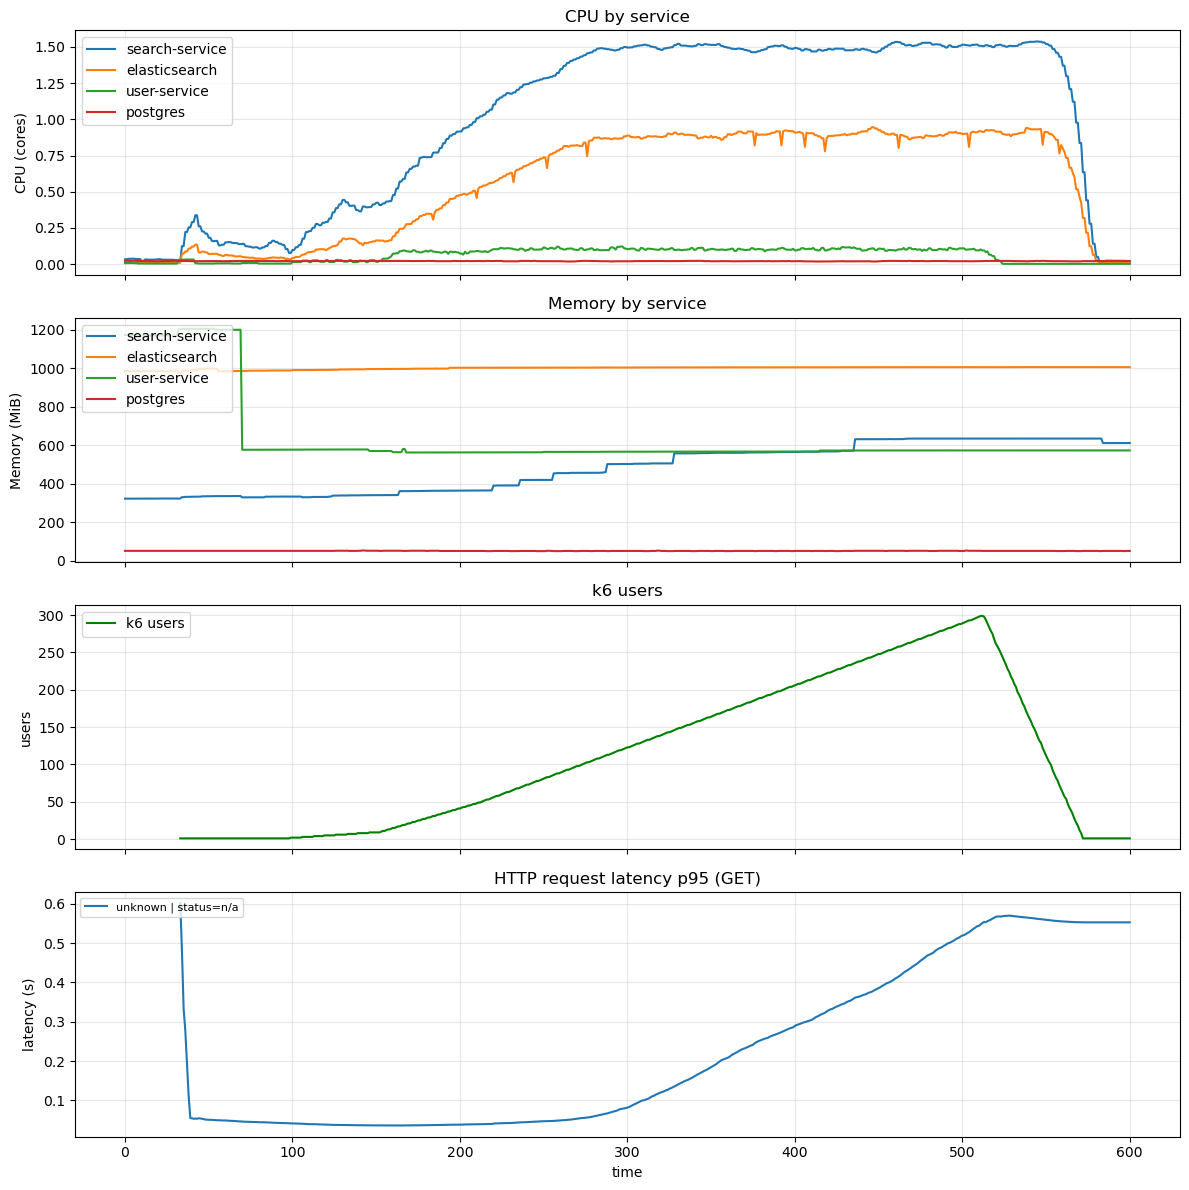

In [24]:
# --- helper: find column containing metric prefix + service name ---
def col_for(metric_prefix: str, service_substring: str) -> str:
    matches = [c for c in df.columns if c.startswith(metric_prefix) and service_substring in c]
    if not matches:
        raise ValueError(f"No column found for prefix='{metric_prefix}' and service='{service_substring}'")
    return matches[0]

services = {
    "search-service": "search-service",
    "elasticsearch": "elasticsearch",
    "user-service": "user-service",
    # "backend_monolith": "app",
    "postgres": "postgres.1",
}

cpu_cols = {label: col_for("cpu_by_svc__", needle) for label, needle in services.items()}
mem_cols = {label: col_for("mem_by_svc__", needle) for label, needle in services.items()}

# memory in MiB for readability
mem_mib = {label: df[col] / (1024 * 1024) for label, col in mem_cols.items()}

# optional graph: k6 users
k6_users_col = next((c for c in df.columns if c.startswith("k6_users__")), None)

# HTTP latency p95 columns for GET methods only
http_get_latency_cols = [
    c for c in df.columns
    if c.startswith("http_rt_latency__")
]

# nicer label for HTTP latency legend
def latency_label(col: str) -> str:
    name_match = re.search(r"'name': '([^']+)'", col)
    status_match = re.search(r"'status': '([^']+)'", col)
    error_match = re.search(r"'error': '([^']+)'", col)

    name = name_match.group(1) if name_match else "unknown"
    status = status_match.group(1) if status_match else "n/a"

    if error_match:
        return f"{name} | err={error_match.group(1)} | status={status}"
    return f"{name} | status={status}"

# --- plot ---
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(12, 12))

# 1) CPU
for label, col in cpu_cols.items():
    axes[0].plot(df.index, df[col], label=label)
axes[0].set_title("CPU by service")
axes[0].set_ylabel("CPU (cores)")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left")

# 2) Memory
for label, series in mem_mib.items():
    axes[1].plot(df.index, series, label=label)
axes[1].set_title("Memory by service")
axes[1].set_ylabel("Memory (MiB)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left")

# 3) k6 users (optional)
if k6_users_col is not None:
    axes[2].plot(df.index, df[k6_users_col], color="green", label="k6 users")
    axes[2].legend(loc="upper left")
axes[2].set_title("k6 users")
axes[2].set_ylabel("users")
axes[2].grid(True, alpha=0.3)

# 4) HTTP latency p95 (GET only)
# todo the http get latency is only one value, calculate when it crosses the 1000ms 
if http_get_latency_cols:
    for col in http_get_latency_cols:
        axes[3].plot(df.index, df[col], label=latency_label(col))
    axes[3].legend(loc="upper left", fontsize=8)
else:
    axes[3].text(0.5, 0.5, "No GET latency columns found", ha="center", va="center", transform=axes[3].transAxes)

axes[3].set_title("HTTP request latency p95 (GET)")
axes[3].set_ylabel("latency (s)")
axes[3].set_xlabel("time")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

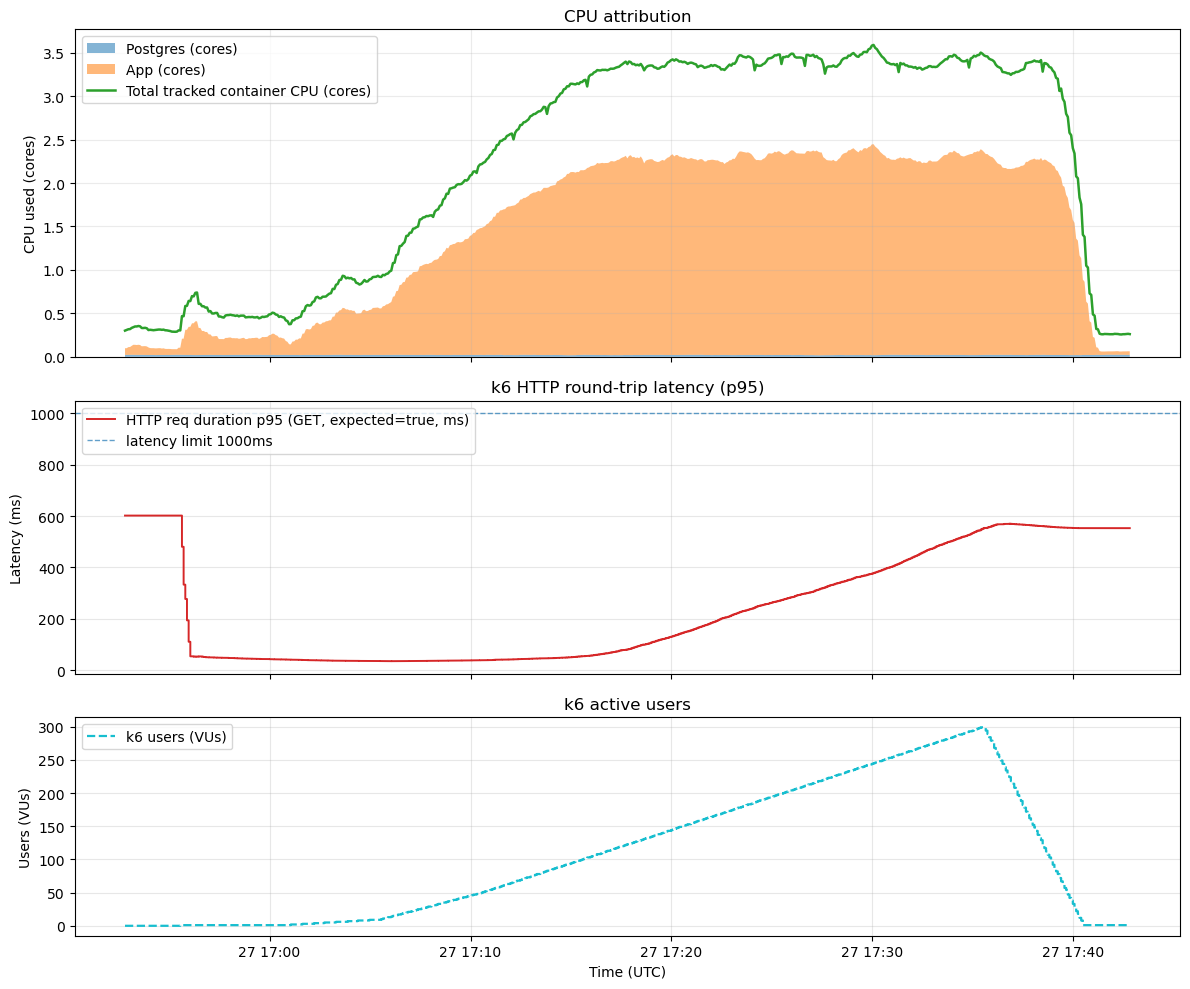

HTTP p95 never exceeded 1000 ms in selected range.


In [25]:
# ---- Build chart series directly from loaded CSV df ----
work_df = df.copy()
work_df["timestamp"] = pd.to_datetime(work_df["timestamp"], utc=True)
work_df = work_df.set_index("timestamp").sort_index()


def sum_service(prefix: str, service_token: str) -> pd.Series:
    cols = [c for c in work_df.columns if c.startswith(prefix) and service_token in c]
    if not cols:
        return pd.Series(index=work_df.index, data=0.0)
    return work_df[cols].fillna(0.0).sum(axis=1)


# CPU attribution built from container-level CSV metrics
s_pg = sum_service("cpu_by_svc__", "chat-eda_postgres.1") + sum_service("cpu_by_svc__", "chat-monolith_postgres.1")
s_app = (
    sum_service("cpu_by_svc__", "chat-eda_user-service")
    + sum_service("cpu_by_svc__", "chat-eda_search-service")
    + sum_service("cpu_by_svc__", "chat-eda_gateway")
    + sum_service("cpu_by_svc__", "chat-eda_ws-service")
    + sum_service("cpu_by_svc__", "app")
)
s_vm = work_df[[c for c in work_df.columns if c.startswith("cpu_by_svc__")]].fillna(0.0).sum(axis=1)

cpu_df = pd.concat(
    [
        s_vm.rename("vm"),
        s_pg.rename("postgres"),
        s_app.rename("app"),
    ],
    axis=1,
).interpolate(limit_direction="both")

# k6 users and HTTP p95 built from CSV columns
k6_users_cols = [c for c in work_df.columns if c.startswith("k6_users__")]
k6_users = work_df[k6_users_cols].fillna(0.0).sum(axis=1) if k6_users_cols else pd.Series(dtype=float)

lat_cols = [
    c
    for c in work_df.columns
    if c.startswith("http_rt_latency__")
]
http_rt_latency = work_df[lat_cols].mean(axis=1, skipna=True) if lat_cols else pd.Series(dtype=float)

# ---- 3 rows: CPU (top), HTTP latency (middle), k6 users (bottom) ----
fig, (ax_cpu, ax_lat, ax_k6) = plt.subplots(
    3, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [1.2, 1, 0.8]}
)

# ========== TOP: CPU attribution ==========
ax_cpu.stackplot(
    cpu_df.index,
    cpu_df["postgres"],
    cpu_df["app"],
    labels=["Postgres (cores)", "App (cores)"],
    alpha=0.55,
)
ax_cpu.plot(cpu_df.index, cpu_df["vm"], lw=1.8, label="Total tracked container CPU (cores)")

ax_cpu.set_title("CPU attribution")
ax_cpu.set_ylabel("CPU used (cores)")
ax_cpu.grid(True, alpha=0.25)
ax_cpu.legend(loc="upper left")

# ========== MIDDLE: HTTP latency ==========
cross_ts = None
cross_val_ms = None

if not http_rt_latency.empty and not http_rt_latency.isna().all():
    s = http_rt_latency.ffill().bfill() * 1000  # seconds -> ms
    ax_lat.step(
        s.index, s.values, where="post",
        color="tab:red", linewidth=1.4,
        label="HTTP req duration p95 (GET, expected=true, ms)"
    )

    crossed = s[s > 1000]
    if not crossed.empty:
        cross_ts = crossed.index[0]
        cross_val_ms = float(crossed.iloc[0])
else:
    ax_lat.text(
        0.5, 0.5, "No data in http_rt_latency",
        ha="center", va="center", transform=ax_lat.transAxes
    )

ax_lat.axhline(
    1000, color="tab:blue", linestyle="--", linewidth=1, alpha=0.7,
    label="latency limit 1000ms"
)
ax_lat.set_title("k6 HTTP round-trip latency (p95)")
ax_lat.set_ylabel("Latency (ms)")
ax_lat.grid(True, alpha=0.3)

# ========== BOTTOM: k6 users ==========
if not k6_users.empty:
    s_u = k6_users
    ax_k6.step(
        s_u.index, s_u.values, where="post",
        color="tab:cyan", lw=1.6, linestyle="--", label="k6 users (VUs)"
    )
else:
    ax_k6.text(
        0.5, 0.5, "No data in k6_users",
        ha="center", va="center", transform=ax_k6.transAxes
    )

ax_k6.set_title("k6 active users")
ax_k6.set_xlabel("Time (UTC)")
ax_k6.set_ylabel("Users (VUs)")
ax_k6.grid(True, alpha=0.3)

# ========== Vertical marker on all subplots ==========
if cross_ts is not None:
    for ax in (ax_cpu, ax_lat, ax_k6):
        ax.axvline(cross_ts, color="magenta", linestyle="--", linewidth=1.2, alpha=0.9)

    if not k6_users.empty:
        s_u = k6_users
        nearest_idx = s_u.index.get_indexer([cross_ts], method="nearest")[0]
        users_at_cross = float(s_u.iloc[nearest_idx])
        ax_lat.annotate(
            f">1000ms at {users_at_cross:.0f} VUs",
            xy=(cross_ts, cross_val_ms),
            xytext=(8, 8),
            textcoords="offset points",
            color="magenta",
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc="white",      # background fill
                ec="magenta",    # border color
                lw=1,
                alpha=0.9
            )
        )

ax_lat.legend(loc="upper left")
ax_k6.legend(loc="upper left")

plt.tight_layout()
plt.show()

# ---- print threshold crossing info ----
if cross_ts is None:
    print("HTTP p95 never exceeded 1000 ms in selected range.")
else:
    print(f"First HTTP p95 > 1000 ms at: {cross_ts}")
    print(f"Latency at crossing: {cross_val_ms:.2f} ms")

    if not k6_users.empty:
        s_u = k6_users
        nearest_idx = s_u.index.get_indexer([cross_ts], method="nearest")[0]
        users_at_cross = float(s_u.iloc[nearest_idx])
        print(f"k6 users near crossing: {users_at_cross:.0f}")

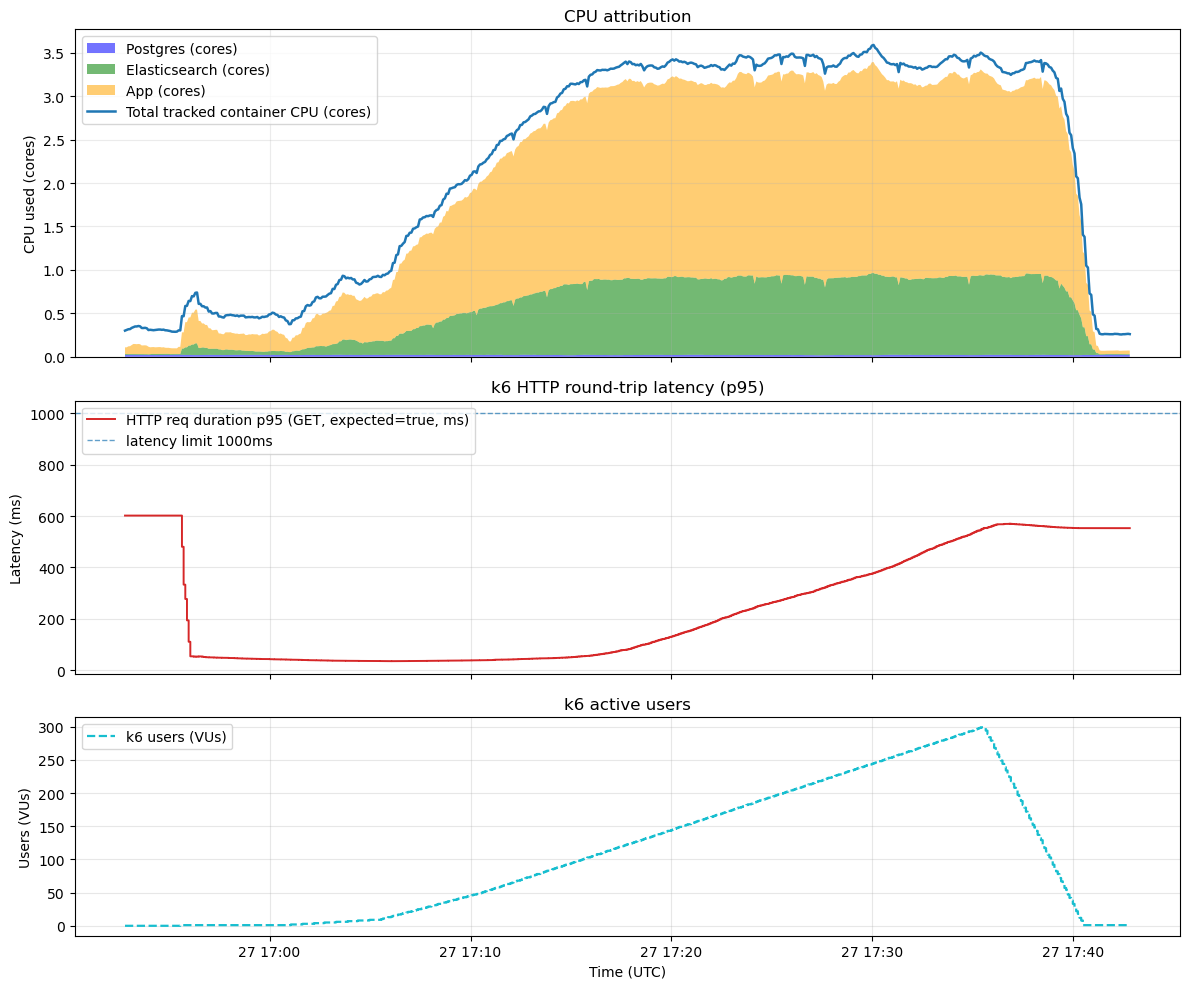

HTTP p95 never exceeded 1000 ms in selected range.


In [26]:
# Updated plotting block: includes optional Elasticsearch CPU in top chart
work_df = df.copy()
work_df["timestamp"] = pd.to_datetime(work_df["timestamp"], utc=True)
work_df = work_df.set_index("timestamp").sort_index()


def sum_service(prefix: str, service_token: str) -> pd.Series:
    cols = [c for c in work_df.columns if c.startswith(prefix) and service_token in c]
    if not cols:
        return pd.Series(index=work_df.index, data=0.0)
    return work_df[cols].fillna(0.0).sum(axis=1)


# CPU attribution built from container-level CSV metrics
s_pg = sum_service("cpu_by_svc__", "chat-eda_postgres.1") + sum_service("cpu_by_svc__", "chat-monolith_postgres.1")
s_app = (
    sum_service("cpu_by_svc__", "chat-eda_user-service")
    + sum_service("cpu_by_svc__", "chat-eda_search-service")
    + sum_service("cpu_by_svc__", "chat-eda_gateway")
    + sum_service("cpu_by_svc__", "chat-eda_ws-service")
    + sum_service("cpu_by_svc__", "app")
)

has_es = any(
    c.startswith("cpu_by_svc__")
    and (
        "chat-eda_elasticsearch.1" in c
        or "chat-monolith_elasticsearch.1" in c
    )
    for c in work_df.columns
)
s_es = (
    sum_service("cpu_by_svc__", "chat-eda_elasticsearch.1")
    + sum_service("cpu_by_svc__", "chat-monolith_elasticsearch.1")
)

s_vm = work_df[[c for c in work_df.columns if c.startswith("cpu_by_svc__")]].fillna(0.0).sum(axis=1)

cpu_parts = [
    s_vm.rename("vm"),
    s_pg.rename("postgres"),
    s_app.rename("app"),
]
if has_es:
    cpu_parts.insert(2, s_es.rename("elasticsearch"))

cpu_df = pd.concat(cpu_parts, axis=1).interpolate(limit_direction="both")

# k6 users and HTTP p95 built from CSV columns
k6_users_cols = [c for c in work_df.columns if c.startswith("k6_users__")]
k6_users = work_df[k6_users_cols].fillna(0.0).sum(axis=1) if k6_users_cols else pd.Series(dtype=float)

lat_cols = [
    c
    for c in work_df.columns
    if c.startswith("http_rt_latency__")
]
http_rt_latency = work_df[lat_cols].mean(axis=1, skipna=True) if lat_cols else pd.Series(dtype=float)

# ---- 3 rows: CPU (top), HTTP latency (middle), k6 users (bottom) ----
fig, (ax_cpu, ax_lat, ax_k6) = plt.subplots(
    3, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [1.2, 1, 0.8]}
)

# ========== TOP: CPU attribution ==========
if "elasticsearch" in cpu_df.columns:
    ax_cpu.stackplot(
        cpu_df.index,
        cpu_df["postgres"],
        cpu_df["elasticsearch"],
        cpu_df["app"],
        labels=["Postgres (cores)", "Elasticsearch (cores)", "App (cores)"],
        colors=["blue", "green", "orange"],
        alpha=0.55,
    )
else:
    ax_cpu.stackplot(
        cpu_df.index,
        cpu_df["postgres"],
        cpu_df["app"],
        labels=["Postgres (cores)", "App (cores)"],
        alpha=0.55,
    )

ax_cpu.plot(cpu_df.index, cpu_df["vm"], lw=1.8, label="Total tracked container CPU (cores)")

ax_cpu.set_title("CPU attribution")
ax_cpu.set_ylabel("CPU used (cores)")
ax_cpu.grid(True, alpha=0.25)
ax_cpu.legend(loc="upper left")

# ========== MIDDLE: HTTP latency ==========
cross_ts = None
cross_val_ms = None

if not http_rt_latency.empty and not http_rt_latency.isna().all():
    s = http_rt_latency.ffill().bfill() * 1000  # seconds -> ms
    ax_lat.step(
        s.index, s.values, where="post",
        color="tab:red", linewidth=1.4,
        label="HTTP req duration p95 (GET, expected=true, ms)"
    )

    crossed = s[s > 1000]
    if not crossed.empty:
        cross_ts = crossed.index[0]
        cross_val_ms = float(crossed.iloc[0])
else:
    ax_lat.text(
        0.5, 0.5, "No data in http_rt_latency",
        ha="center", va="center", transform=ax_lat.transAxes
    )

ax_lat.axhline(
    1000, color="tab:blue", linestyle="--", linewidth=1, alpha=0.7,
    label="latency limit 1000ms"
)
ax_lat.set_title("k6 HTTP round-trip latency (p95)")
ax_lat.set_ylabel("Latency (ms)")
ax_lat.grid(True, alpha=0.3)

# ========== BOTTOM: k6 users ==========
if not k6_users.empty:
    s_u = k6_users
    ax_k6.step(
        s_u.index, s_u.values, where="post",
        color="tab:cyan", lw=1.6, linestyle="--", label="k6 users (VUs)"
    )
else:
    ax_k6.text(
        0.5, 0.5, "No data in k6_users",
        ha="center", va="center", transform=ax_k6.transAxes
    )

ax_k6.set_title("k6 active users")
ax_k6.set_xlabel("Time (UTC)")
ax_k6.set_ylabel("Users (VUs)")
ax_k6.grid(True, alpha=0.3)

# ========== Vertical marker on all subplots ==========
if cross_ts is not None:
    for ax in (ax_cpu, ax_lat, ax_k6):
        ax.axvline(cross_ts, color="magenta", linestyle="--", linewidth=1.2, alpha=0.9)

    if not k6_users.empty:
        s_u = k6_users
        nearest_idx = s_u.index.get_indexer([cross_ts], method="nearest")[0]
        users_at_cross = float(s_u.iloc[nearest_idx])
        ax_lat.annotate(
            f">1000ms at {users_at_cross:.0f} VUs",
            xy=(cross_ts, cross_val_ms),
            xytext=(8, 8),
            textcoords="offset points",
            color="magenta",
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc="white",
                ec="magenta",
                lw=1,
                alpha=0.9
            )
        )

ax_lat.legend(loc="upper left")
ax_k6.legend(loc="upper left")

plt.tight_layout()
plt.show()

if cross_ts is None:
    print("HTTP p95 never exceeded 1000 ms in selected range.")
else:
    print(f"First HTTP p95 > 1000 ms at: {cross_ts}")
    print(f"Latency at crossing: {cross_val_ms:.2f} ms")

    if not k6_users.empty:
        s_u = k6_users
        nearest_idx = s_u.index.get_indexer([cross_ts], method="nearest")[0]
        users_at_cross = float(s_u.iloc[nearest_idx])
        print(f"k6 users near crossing: {users_at_cross:.0f}")